# Problem Statement

#### The objective of this analysis is to explore how market sentiment (Fear vs Greed) influences trader behavior, risk-taking, and profitability using historical trader data and Bitcoin market sentiment data.

# Import Libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")


# Load RAW Data

In [51]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")


In [52]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [53]:
trades.tail()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,25-04-2025 15:35,7546.6,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,25-04-2025 15:35,7164.4,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,25-04-2025 15:35,5040.3,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,25-04-2025 15:35,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,25-04-2025 15:35,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12


In [54]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [55]:
sentiment.tail()

,timestamp,value,classification,date
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


# Checking the null values

In [56]:
trades.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [57]:
sentiment.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

# Checking Duplicates

In [58]:
trades.duplicated().sum()

0

In [59]:
sentiment.duplicated().sum()


0

# Checking The Distribtion 

In [78]:
trades.describe()

,execution_price,size_tokens,size_usd,start_position,closed_pnl,order_id,fee,trade_id,timestamp
count,211224.000000,2.112240e+05,2.112240e+05,2.112240e+05,211224.000000,2.112240e+05,211224.000000,2.112240e+05,211224
mean,11414.723350,4.623365e+03,5.639451e+03,-2.994625e+04,48.749001,6.965388e+10,1.163967,5.628549e+14,2025-01-24 18:44:50.421542912
min,0.000005,8.740000e-07,0.000000e+00,-1.433463e+07,-117990.104100,1.732711e+08,-1.175712,0.000000e+00,2023-03-28 10:40:00
25%,4.854700,2.940000e+00,1.937900e+02,-3.762311e+02,0.000000,5.983853e+10,0.016121,2.810000e+14,2025-02-19 21:20:00
50%,18.280000,3.200000e+01,5.970450e+02,8.472793e+01,0.000000,7.442939e+10,0.089578,5.620000e+14,2025-02-19 21:20:00
75%,101.580000,1.879025e+02,2.058960e+03,9.337278e+03,5.792797,8.335543e+10,0.393811,8.460000e+14,2025-02-19 21:20:00
max,109004.000000,1.582244e+07,3.921431e+06,3.050948e+07,135329.090100,9.014923e+10,837.471593,1.130000e+15,2025-06-15 15:06:40
std,29447.654868,1.042729e+05,3.657514e+04,6.738074e+05,919.164828,1.835753e+10,6.758854,3.257565e+14,NaN


In [79]:
sentiment.describe()

,timestamp,value
count,2644,2644.000000
mean,2021-09-17 17:14:45.022693120,46.981089
min,2018-02-01 05:30:00,5.000000
25%,2019-11-26 23:30:00,28.000000
50%,2021-09-17 17:30:00,46.000000
75%,2023-07-10 11:30:00,66.000000
max,2025-05-02 05:30:00,95.000000
std,NaN,21.827680


# Clean column names

In [60]:
trades.columns = (
    trades.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

sentiment.columns = (
    sentiment.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)


# FIX TRADES TIMESTAMP

In [61]:
trades["timestamp"] = trades["timestamp"].astype("int64")
trades["timestamp"] = pd.to_datetime(trades["timestamp"], unit="ms")
trades["date"] = trades["timestamp"].dt.strftime("%Y-%m-%d")


In [62]:
trades["date"].min(), trades["date"].max()


('2023-03-28', '2025-06-15')

# FIX SENTIMENT TIMESTAMP

In [63]:
sentiment["timestamp"] = pd.to_datetime(sentiment["timestamp"], unit="s")



In [64]:
sentiment["date"] = sentiment["timestamp"].dt.strftime("%Y-%m-%d")


In [65]:
sentiment["date"].min(), sentiment["date"].max()


('2018-02-01', '2025-05-02')

# Binary sentiment

In [66]:
sentiment["sentiment_binary"] = sentiment["classification"].map({
    "Extreme Fear": "Fear",
    "Fear": "Fear",
    "Neutral": "Fear",
    "Greed": "Greed",
    "Extreme Greed": "Greed"
})


#### One sentiment per day

In [67]:
sentiment_daily = (
    sentiment
    .sort_values("timestamp")
    .drop_duplicates(subset="date", keep="last")
)

sentiment_daily["date"].is_unique


True

# MERGE

In [68]:
df = trades.merge(
    sentiment_daily[["date", "sentiment_binary"]],
    on="date",
    how="left"
)

df.rename(columns={"sentiment_binary": "classification"}, inplace=True)


In [69]:
df["classification"].value_counts(dropna=False)


classification
Fear     141012
Greed     43251
NaN       26961
Name: count, dtype: int64

# Feature Engineering

In [70]:
df["is_profitable"] = df["closed_pnl"] > 0
df["trade_size_abs"] = df["size_usd"].abs()


# Clean for Analysis

In [71]:
df_eda = df[df["classification"].notna()].copy()


# Exploratory Data Analysis (EDA)

#### Trade count by sentiment

In [72]:
df_eda.groupby("classification").size()


classification
Fear     141012
Greed     43251
dtype: int64

#### Average PnL

In [73]:
df_eda.groupby("classification")["closed_pnl"].mean()


classification
Fear     48.638893
Greed    77.838247
Name: closed_pnl, dtype: float64

#### Median PnL

In [74]:
df_eda.groupby("classification")["closed_pnl"].median()


classification
Fear     0.0
Greed    0.0
Name: closed_pnl, dtype: float64

# What I observed

Fear periods account for a significantly higher number of trades compared to Greed.

Average PnL is higher during Greed periods, likely driven by a smaller number of large winning trades.

Median PnL is zero for both sentiments, indicating that most trades close near breakeven.

# Why it matters

Median PnL provides a more robust view of typical trader performance than mean PnL.

The gap between mean and median highlights the presence of strong outliers.

This suggests that a small subset of trades drives overall profitability, emphasizing the importance of risk management.

In [75]:
# Win rate by sentiment
df_eda.groupby("classification")["is_profitable"].mean()


classification
Fear     0.410185
Greed    0.453492
Name: is_profitable, dtype: float64

This shows percentage of profitable trades

# VISUAL – PnL Distribution

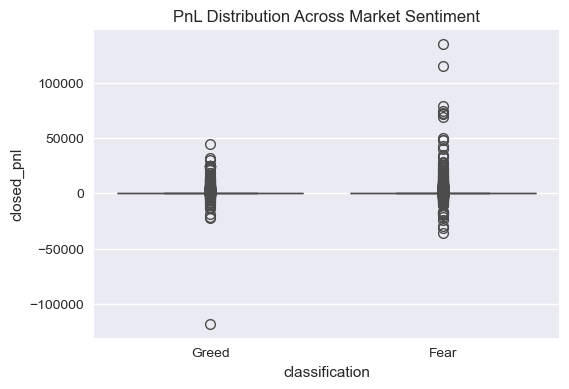

In [76]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_eda, x="classification", y="closed_pnl")
plt.title("PnL Distribution Across Market Sentiment")
plt.show()


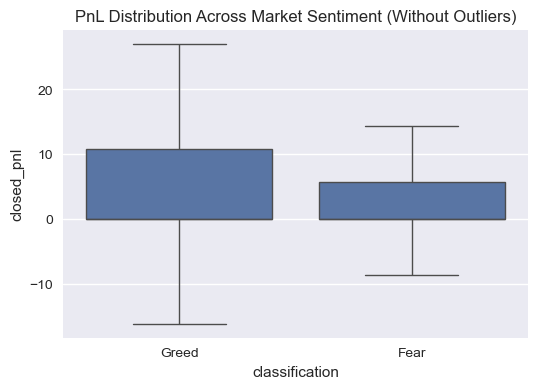

In [77]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_eda, x="classification", y="closed_pnl", showfliers=False)
plt.title("PnL Distribution Across Market Sentiment (Without Outliers)")
plt.show()


## Key Insights from Analysis

- Trading activity is significantly higher during Fear market conditions, indicating increased participation during uncertainty.
- Greed periods, while having fewer trades, exhibit higher average profitability driven by a smaller number of high-impact trades.
- Median PnL is zero across both sentiments, suggesting that most trades close near breakeven and overall profits are driven by outliers.
- Fear markets show a wider PnL distribution, reflecting higher volatility and risk compared to Greed markets.
- Removing outliers reveals that typical trade outcomes are tightly clustered, emphasizing the importance of risk management and position sizing.


# Final Summary 

In this analysis, I studied how Bitcoin market sentiment (Fear vs Greed) impacts trader behavior using historical trade data.

The results show that Fear periods account for a higher number of trades, indicating increased participation during cautious market conditions. Greed periods, while having fewer trades, exhibit higher average PnL driven by a small number of large winning trades.

Median PnL remains close to zero across both sentiments, highlighting that most trades close near breakeven and that profitability is driven by outliers.

Overall, market sentiment affects risk distribution more than typical returns, suggesting that sentiment-aware risk management can improve trading strategies.

# Limitations:
Sentiment is measured at a daily level, while trades are intraday. As a result, all trades within a day are assigned the same sentiment, which may smooth short-term market fluctuations.

# Final Conclusion 

This analysis shows that market sentiment significantly impacts trader behavior. Fear periods see higher participation and greater volatility, while Greed periods produce higher average profits driven by a small number of large winning trades. Although most trades close near breakeven, sentiment clearly influences risk distribution, highlighting the importance of sentiment-aware trading and risk management strategies.